## Nonlinear classification toy example
In the following example, we will consider a synthetic classification problem of a nonlinear nature, so that linear models (such as SVC or logistic regression) do not do very well.

The input data is two-dimensional, so that we can visualize what is going on.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

%config InlineBackend.figure_format = 'svg'
plt.style.use('bmh')
plt.rcParams['image.cmap'] = 'Paired_r'

We make some data (800 instances) and split it into training and test sets (400 each).

As you can see, the blue dots tend to be situated in an ellipsis-shaped region near the middle, and the red dots outside this region.

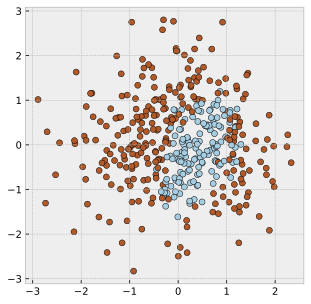

In [2]:
np.random.seed(5)


def f(X):
    X = X.copy()
    X[:, 0] -= 0.4
    X[:, 1] += 0.2
    return 1.1*X[:, 0]**2 + 0.3*X[:, 1]**2 - 0.6*X[:, 0]*X[:, 1]


def make_data():
    N = 800
    X = np.random.normal(size=(N, 2))
    Y = f(X) < 0.5
    X += np.random.normal(size=(N, 2), scale=0.2)
    return X, Y


X, Y = make_data()

Xtrain, Xtest, Ytrain, Ytest = train_test_split(
    X, Y, random_state=0, test_size=0.5)

plt.figure(figsize=(5, 5))
plt.scatter(Xtrain[:, 0], Xtrain[:, 1], c=Ytrain, edgecolors='k');

We make a helper function that can plot the dataset and the decision boundary of a classifier.

This code was adapted from an [example](http://scikit-learn.org/stable/auto_examples/svm/plot_iris.html) in scikit-learn's documentation.

In [3]:
def plot_boundary(clf, X, Y):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 10*h, X[:, 0].max() + 10*h
    y_min, y_max = X[:, 1].min() - 10*h, X[:, 1].max() + 10*h
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(5, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.contour(xx, yy, Z, colors='k', linewidths=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolors='k');

First, let's see how well a majority baseline is doing.

In [4]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(Xtrain, Ytrain)
accuracy_score(Ytest, dummy.predict(Xtest))

0.68

Now we consider a linear classifier (logistic regression). This classifier is completely helpless for this type of data, because of the elliptic shape of the region where the blue dots are situated. Drawing a straight line can't separate the classes. The LR classifier is doing even worse than the dummy baseline.

0.5325

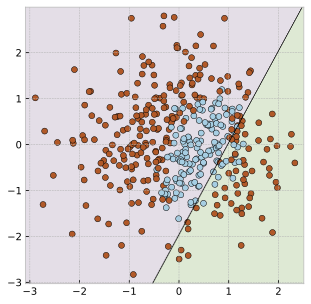

In [5]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression().fit(Xtrain, Ytrain)

plot_boundary(clf, Xtrain, Ytrain)
accuracy_score(Ytest, clf.predict(Xtest))

### Avoiding linear inseparability by transforming features

One way to make linear classifiers work when we have some data that is not linearly separable is to apply a transformation to the data. In this case, we add an additional feature: $x_3 = x_1^2 + x_2^2$. After adding the additional feature, the logistic regression classifier works better. This example is more or less identical to the discussion [here](https://monkeylearn.com/blog/introduction-to-support-vector-machines-svm/).

We can note that the pipeline *as a whole* is no longer a linear classifier, because it includes the transformation. We can see that the decision boundary is now a circle, not a straight line.

0.8525

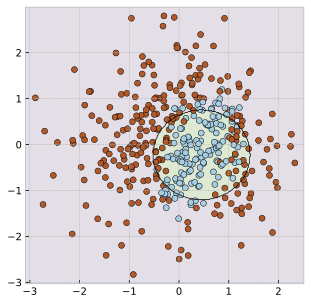

In [6]:
from sklearn.pipeline import make_pipeline

# To add the extra feature to our training data, we make a
# helper class FeatureExtender that we can put into a pipeline.


class FeatureExtender:

    def fit(self, X, Y=None):
        return self

    def transform(self, X, Y=None):

        # We compute a new column, by summing the squares of the
        # two other columns.
        new_column = X[:, 0]**2 + X[:, 1]**2

        # Add the new column to the matrix.
        # (np.c_ is a utility to add a column.)
        return np.c_[X, new_column]


pipeline = make_pipeline(
    FeatureExtender(),
    LogisticRegression()
)

pipeline.fit(Xtrain, Ytrain)

plot_boundary(pipeline, Xtrain, Ytrain)

accuracy_score(Ytest, pipeline.predict(Xtest))

Let's also visualize the feature transformation. It's a bit hard to see exactly what is going on in the three-dimensional plot, but the intuition is that by adding a third axis, our data becomes easier to separate for a linear separator. (Blue dots tend to be near the bottom in this case.)

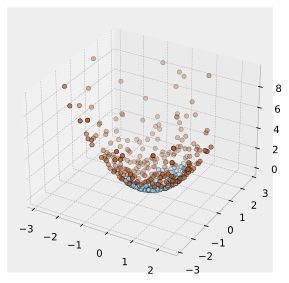

In [7]:
from mpl_toolkits.mplot3d import Axes3D

X3 = FeatureExtender().transform(Xtrain)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X3[:, 0], X3[:, 1], X3[:, 2], c=Ytrain,
           cmap='Paired_r', edgecolors='k');

### Nonlinear support vector classifiers using kernels

It seems a bit primitive to have to design this transformation manually. Later in the course, we will discuss neural networks ([MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) in scikit-learn), where the nonlinear transformations are learned automatically.

For now, we will see how some linear classifiers can be extended to handle data that is not linearly separable. In particular, we will explore nonlinear, kernel-based support vector classifiers. In scikit-learn, they are implemented in the class [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html), as oppposed to LinearSVC that we used previously.

In [8]:
from sklearn.svm import SVC

In theory, kernel-based classifiers are based on the idea we explored above: mapping the original features into a transformed vector space, where we hope that the two classes are more or less linearly separable. But the crucial idea with kernel-based classifiers, called the [*kernel trick*](https://en.wikipedia.org/wiki/Kernel_method), is that *the mapping is not computed explicitly*. Instead, we just need to compute the dot product in the transformed space. This "implicit" dot product is called a kernel. The transformed space may have a very high dimensionality (sometimes even infinite), so we may save a lot of computation by not having to carry out the transformation explicitly.

When you use the `SVC` in scikit-learn, you can specify what kernel to use. See [the documentation](https://scikit-learn.org/stable/modules/svm.html#svm-kernels) for how to select a kernel and set its parameters.

The simplest kernel is called `linear`, where the kernel is just a normal dot product. This just gives us a linear classifier, so it's not useful for us in this case. The classifier can't separate the classes, and the accuracy becomes equal to that of the dummy baseline.

In [9]:
clf = SVC(kernel='linear').fit(Xtrain, Ytrain)

accuracy_score(Ytest, clf.predict(Xtest))

0.68

One of the simplest *nonlinear* kernels is called a *polynomial kernel*. This is just a polynomial function of the normal dot product.

For instance, in the following example, we will use the kernel
$$
K(x_1, x_2) = (x_1\cdot x_2 + 1)^2
$$
(Here, `coef0` is the "offset" 1 and `degree` is the polynomial degree of 2.) It can be shown that by using a polynomial kernel with degree 2, we are *implicitly* forming combinations of 2 features. See exercise 7.3(b) in the first exercise sheet if you want to work out the details. The implicit feature space will be quite similar to our manual transformation we carried out using the `FeatureExtender`.

When using this kernel, our classifier is doing quite well.

0.9125

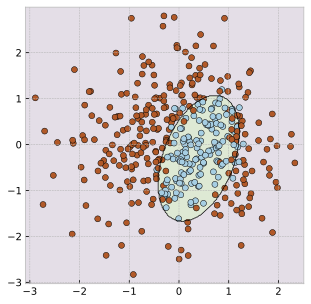

In [10]:
clf = SVC(kernel='poly', degree=2, coef0=1).fit(Xtrain, Ytrain)

plot_boundary(clf, Xtrain, Ytrain)
accuracy_score(Ytest, clf.predict(Xtest))

The default kernel in `SVC` is the [radial basis function kernel](https://en.wikipedia.org/wiki/Radial_basis_function_kernel) (RBF). In this case, the implicit feature space has an *infinite* dimensionality and it consists of an infinite number of combinations of the original features.

This also works well with the synthetic data, although the simpler kernel above gave a slighly higher accuracy.

0.9075

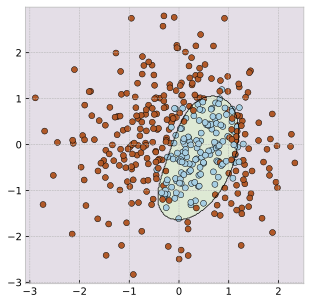

In [11]:
clf = SVC().fit(Xtrain, Ytrain)

plot_boundary(clf, Xtrain, Ytrain)
accuracy_score(Ytest, clf.predict(Xtest))

### Side note: decision trees

We have already covered a type of nonlinear classifier in the course: decision trees. How well does it work with this synthetic data?

At least better than the linear classifiers: the accuracy is well above the dummy baseline. But you can see that it has some trouble because the data is noisy, and the decision boundary is highly irregular. It seems we have a bit of overfitting. To simplify the boundary, you can change the `max_depth` parameter, which is one of the ways that we can mitigate overfitting with decision tree classifiers. Alteratively, we can consider tree-based ensemble models such as [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) and [`GradientBoostingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html), which are less prone to overfitting.

0.87

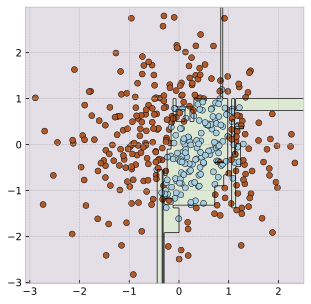

In [12]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier().fit(Xtrain, Ytrain)

plot_boundary(clf, Xtrain, Ytrain)
accuracy_score(Ytest, clf.predict(Xtest))